[1517.0391167760836, 655.3392746547812, 212.35550348922902, 182.8172000029703, 158.50971986268996, 137.8743828856573, 119.60362631120007, 103.46477820589106, 89.0697811234225, 82.87135139013382]
[]


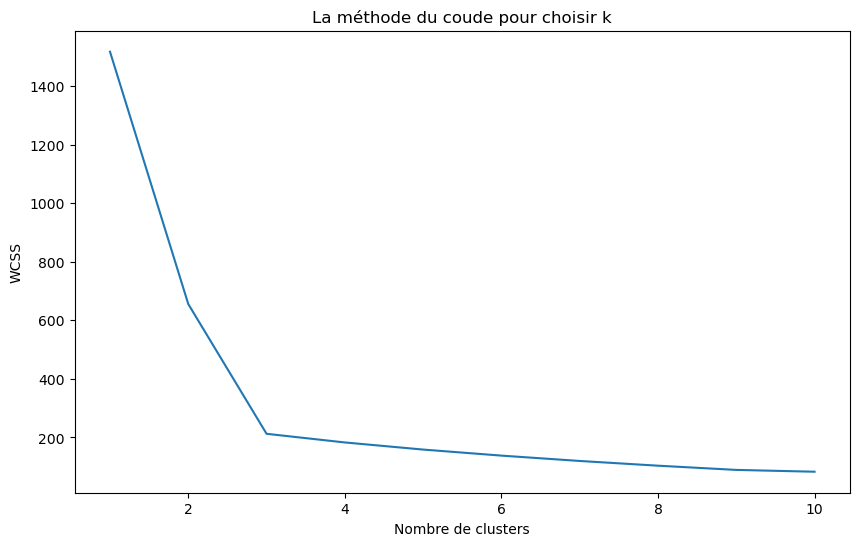

[2 1 2 0 0 0 1 2 0 0 1 1 1 2 1 0 2 2 0 1 0 2 1 2 0 0 2 0 1 1 0 2 2 1 1 0 1
 0 2 1 0 1 2 1 1 0 1 0 0 1 0 1 0 0 1 2 2 0 0 2 1 1 2 0 1 0 2 1 2 1 0 0 0 0
 1 2 1 0 2 2 0 2 1 2 2 2 1 0 2 2 0 1 0 2 1 1 2 1 0 2 1 0 2 1 2 2 0 2 1 1 2
 0 2 2 0 0 2 2 1 1 1 0 1 1 1 0 1 1 1 0 0 0 2 0 0 1 0 2 0 0 1 2 1 2 0 0 2 0
 0 1 2 0 2 1 0 0 1 1 2 1 2 2 1 2 0 2 2 2 2 0 1 2 0 1 1 1 2 1 2 2 1 0 2 2 2
 2 1 0 2 0 2 2 1 1 0 2 1 0 2 0 1 0 2 0 1 0 2 0 2 1 2 2 0 1 1 1 1 2 0 1 2 1
 1 1 2 0 0 2 2 0 2 1 1 2 1 0 0 0 2 2 1 0 0 0 0 1 0 0 2 1 1 2 1 1 0 2 1 0 2
 2 0 2 0 0 2 0 2 1 1 1 1 2 2 2 2 2 0 0 1 2 2 1 1 1 0 1 0 0 1 1 0 0 0 1 2 2
 0 1 2 0]
[2 1 2 0 0 0 1 2 0 0 1 1 1 2 1 0 2 2 0 1 0 2 1 2 0 0 2 0 1 1 0 2 2 1 1 0 1
 0 2 1 0 1 2 1 1 0 1 0 0 1 0 1 0 0 1 2 2 0 0 2 1 1 2 0 1 0 2 1 2 1 0 0 0 0
 1 2 1 0 2 2 0 2 1 2 2 2 1 0 2 2 0 1 0 2 1 1 2 1 0 2 1 0 2 1 2 2 0 2 1 1 2
 0 2 2 0 0 2 2 1 1 1 0 1 1 1 0 1 1 1 0 0 0 2 0 0 1 0 2 0 0 1 2 1 2 0 0 2 0
 0 1 2 0 2 1 0 0 1 1 2 1 2 2 1 2 0 2 2 2 2 0 1 2 0 1 1 1 2 1 2 2 1 0 2 2 2
 2 1 0 2 0 2 2 

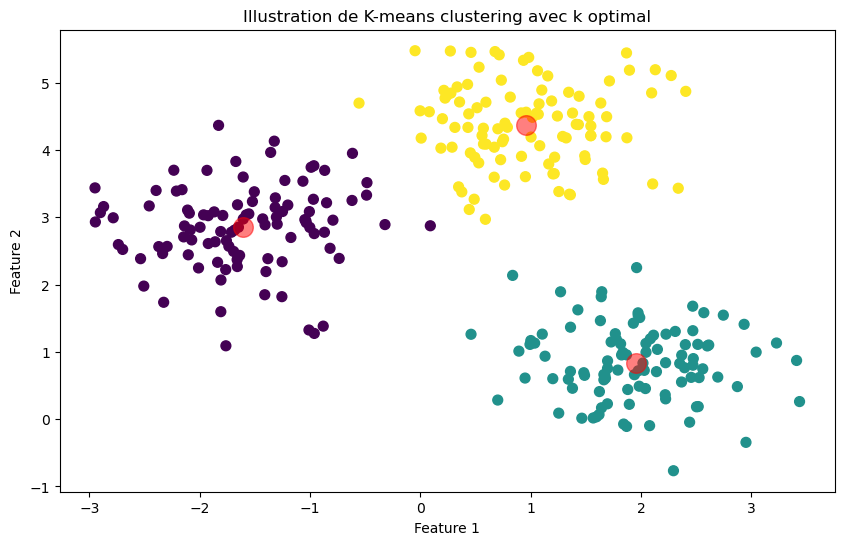

In [19]:
# -*- coding: utf-8 -*-
"""
TP_1

@author: Rath
"""

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import calinski_harabasz_score

# Génération de données aléatoires
X, y = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=0)

# Calculer la somme des carrés des distances pour différents nombres de clusters
wcss = []  # WCSS (Within-Cluster Sum of Square)
__other = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

print(wcss)
print(__other)

# Tracer le graphique du coude pour déterminer le meilleur k
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss)
plt.title('La méthode du coude pour choisir k')
plt.xlabel('Nombre de clusters')
plt.ylabel('WCSS')
plt.show()

# Appliquer K-means avec le k optimal
k_optimal = 3  # Vous pouvez choisir le k en observant le graphique du coude
kmeans_optimal = KMeans(n_clusters=k_optimal, init='k-means++', max_iter=300, n_init=10, random_state=0)
kmeans_optimal.fit(X)
print(kmeans_optimal.labels_)
y_kmeans_optimal = kmeans_optimal.predict(X)

print(y_kmeans_optimal)
# Visualisation des clusters et des centres avec k optimal
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans_optimal, s=50, cmap='viridis')
centers_optimal = kmeans_optimal.cluster_centers_
plt.scatter(centers_optimal[:, 0], centers_optimal[:, 1], c='red', s=200, alpha=0.5)
plt.title('Illustration de K-means clustering avec k optimal')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()
